In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("iris.csv")
df.head()

,sepal.length,sepal.width,petal.length,petal.width,species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [12]:
names= df['species'].value_counts().index
counts= df['species'].value_counts().values



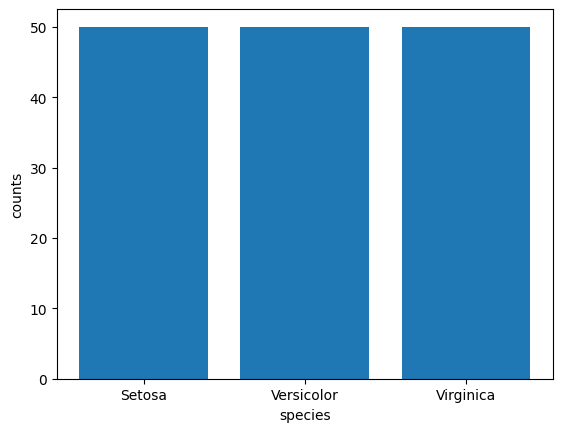

In [17]:
plt.bar(x= names, height=counts)

plt.xlabel('species')
plt.ylabel('counts')
plt.show()

In [19]:
X= df.drop(columns=['species'])
y= df['species']

In [23]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=123)

In [36]:
X_train.head()

,sepal.length,sepal.width,petal.length,petal.width
130,7.4,2.8,6.1,1.9
119,6.0,2.2,5.0,1.5
29,4.7,3.2,1.6,0.2
0,5.1,3.5,1.4,0.2
62,6.0,2.2,4.0,1.0


In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [41]:
knn= KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
print("accuracy=",accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))

accuracy= 0.9666666666666667
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        13
  Versicolor       1.00      0.83      0.91         6
   Virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.94      0.96        30
weighted avg       0.97      0.97      0.97        30



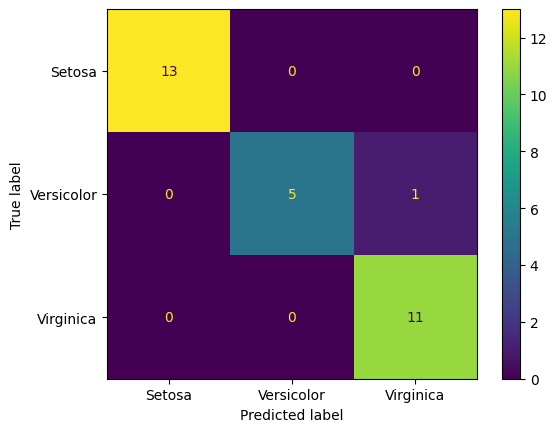

In [47]:
cm = confusion_matrix(y_test, y_pred)
cm_plot= ConfusionMatrixDisplay(cm, display_labels=df['species'].unique())
cm_plot.plot()
plt.savefig('confusion_matrix.png')

In [50]:
test_pred = knn.predict([[5.1,3.5,1.4,.2]])
print(test_pred[0])

Setosa


c:\Users\bhair\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [52]:
import joblib
joblib.dump(knn,'model.joblib')
print('success')

success
